In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.neural_network import MLPClassifier
import optuna
import optuna.visualization as vis
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import logging

In [3]:
def plot_verification(df, name, idx, level):
    plt.figure(figsize=(10, 3))
    plt.plot(df['rms'], color='gray', alpha=0.5, label='Raw RMS')
    plt.axhline(y=level, color='r', linestyle='--', label='Trigger Level')
    plt.axvline(x=idx, color='g', label=f'Detected Onset ({idx})')
    plt.title(f"Detection Logic Check: {name}")
    plt.legend()
    plt.show()


In [ ]:
def prep_final_version(file_path, threshold):
    df = pd.read_csv(file_path)
    split_idx = int(len(df) * threshold)
    df['label'] = 0
    df.iloc[split_idx:, df.columns.get_loc('label')] = 1
    return df


In [ ]:
# Your verified indices
final_indices = {
    "Set 1": 2095, 
    "Set 2": 690, 
    "Set 3": 6200
}

raw_lengths = {
    "Set 1": len(pd.read_csv('normalized_features_set1.csv')),
    "Set 2": len(pd.read_csv('normalized_features_set2.csv')),
    "Set 3": len(pd.read_csv('normalized_features_set3.csv'))
}

# 3. Now calculate thresholds safely
final_thresholds = {name: final_indices[name] / raw_lengths[name] for name in final_indices}

# Prepare the data one last time, marking the point of failure
train1_final = prep_final_version('normalized_features_set1.csv', final_thresholds['Set 1'])
train2_final = prep_final_version('normalized_features_set2.csv', final_thresholds['Set 2'])
test3_final = prep_final_version('normalized_features_set3.csv', final_thresholds['Set 3'])

datasets = {
    "Set 1": train1_final,
    "Set 2": train2_final,
    "Set 3": test3_final
}

train_df = pd.concat([train1_final, train2_final], ignore_index=True)
features = [c for c in train_df.columns if c not in ['timestamp', 'set_id', 'label']]
train_df = pd.concat([train1_final, train2_final], ignore_index=True)
features = [c for c in train_df.columns if c not in ['timestamp', 'set_id', 'label']]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features])
X_test = scaler.transform(test3_final[features])

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_df['label'])

from sklearn.metrics import f1_score
preds = clf.predict(X_test)
print(f"Final F1-Score on Set 3: {f1_score(test3_final['label'], preds):.3f}")

Final F1-Score on Set 3: 0.849


In [ ]:

def calculate_auto_threshold_v2(df, column='rms'):
    # 1. Use the median of the first 20% to establish a stable healthy baseline
    baseline_data = df[column].iloc[:int(len(df) * 0.2)]
    baseline_median = baseline_data.median()
    baseline_std = baseline_data.std()
    
    # 2. Adaptive Trigger: 6 Standard Deviations above the median
    # (Feel free to tweak the '6' if the red line is too high or low)
    trigger_level = baseline_median + (6 * baseline_std)
    
    # 3. Use a rolling mean (window of 25) to find sustained jumps
    rolling_mean = df[column].rolling(window=25).mean()
    
    # Find indices where the sustained signal crosses the trigger
    over_threshold = np.where(rolling_mean > trigger_level)[0]
    
    if len(over_threshold) > 0:
        onset_index = over_threshold[0]
        # Safety check: skip the first 10% to avoid startup noise
        if onset_index < int(len(df) * 0.1):
            remaining_data = rolling_mean.iloc[int(len(df) * 0.1):]
            over_threshold_late = np.where(remaining_data > trigger_level)[0]
            if len(over_threshold_late) > 0:
                onset_index = over_threshold_late[0] + int(len(df) * 0.1)
    else:
        # Default back to 85% if no statistical runaway is detected
        onset_index = int(len(df) * 0.85)
    
    return onset_index, trigger_level

--- Visualizing Final Verified Thresholds ---


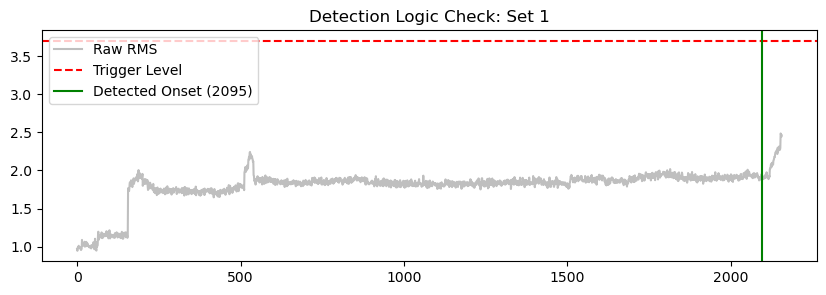

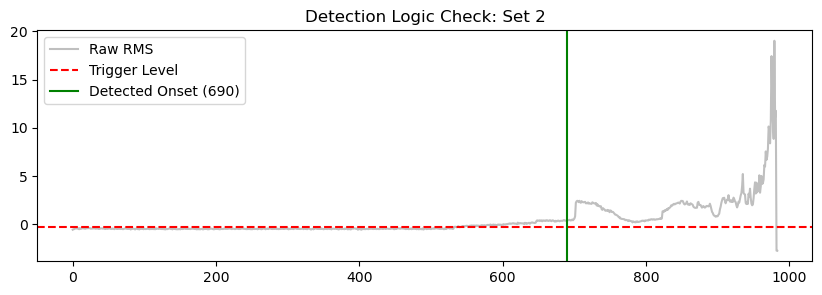

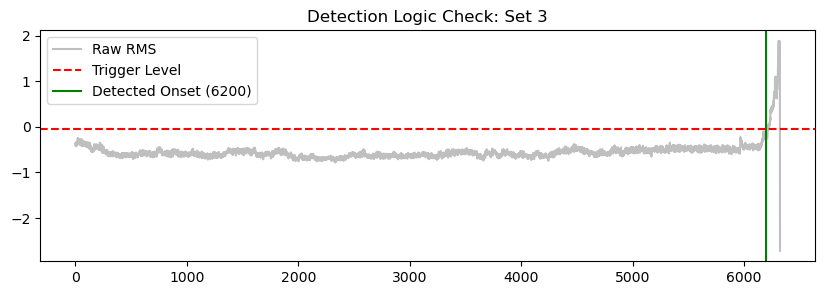

In [218]:
print("--- Visualizing Final Verified Thresholds ---")
for name, df in datasets.items():
    # Grab the manual index for this specific set
    manual_idx = final_indices[name]
    
    # We'll use your robust threshold logic just to get the red 'Level' line
    # If you deleted that function, you can just set level = df['rms'].mean() + (5 * df['rms'].std())
    _, level = calculate_auto_threshold_v2(df) 
    
    plot_verification(df, name, manual_idx, level)

In [ ]:
#logistic regression, autoencoder, mlp

In [190]:
def objective(trial):
    # Use actual feature names for the dictionary keys
    selected_cols = [col for col in features if trial.suggest_categorical(f"use_{col}", [True, False])]
    
    if len(selected_cols) == 0: 
        return 0

    # Subset the DataFrames directly to avoid indexing confusion
    X_train_sub = train_df[selected_cols]
    X_test_sub = test3_final[selected_cols]
    
    # Re-scale based ONLY on the selected features (Crucial for Logistic Regression)
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)
    
    model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
    model.fit(X_train_scaled, train_df['label'])
    
    preds = model.predict(X_test_scaled)
    f1 = f1_score(test3_final['label'], preds)
    
    penalty = 0.005 * len(selected_cols)
    return f1 - penalty

In [210]:
# 1. Cleaner Logging
optuna.logging.set_verbosity(optuna.logging.INFO) # INFO lets you see the best score progress

# 2. Single, Deep Study
print("Starting Deep Feature Search (300 Trials)...")
study = optuna.create_study(
    direction='maximize', 
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run 300 trials in one go
study.optimize(objective, n_trials=300, show_progress_bar=True)

# 3. Extract the winners
robust_features = [col for col in features if study.best_params.get(f"use_{col}", False)]

print(f"\n--- Optimization Finished ---")
print(f"Number of features selected: {len(robust_features)}")
print(f"Selected Feature Set: {robust_features}")
print(f"Best Score: {study.best_value:.4f}")

[I 2026-05-10 22:37:10,269] A new study created in memory with name: no-name-5549fd5a-3cee-4ba4-a95e-89996bf8dbf9


Starting Deep Feature Search (300 Trials)...


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-05-10 22:37:10,405] Trial 0 finished with value: 0.30323529411764705 and parameters: {'use_rms': False, 'use_kurtosis': True, 'use_peak': True, 'use_crest_factor': False, 'use_shape_factor': False, 'use_f_0': False, 'use_f_1': True, 'use_f_2': False, 'use_f_3': False, 'use_f_4': True, 'use_f_5': True, 'use_f_6': False, 'use_f_7': False, 'use_f_8': False, 'use_f_9': True, 'use_f_10': True, 'use_f_11': False, 'use_f_12': True, 'use_f_13': True, 'use_f_14': True, 'use_f_15': False, 'use_f_16': False, 'use_f_17': False, 'use_f_18': False, 'use_f_19': True, 'use_f_20': True, 'use_f_21': True, 'use_f_22': False, 'use_f_23': False, 'use_f_24': False, 'use_f_25': True, 'use_f_26': True, 'use_f_27': False, 'use_f_28': False, 'use_f_29': False, 'use_f_30': True, 'use_f_31': False, 'use_f_32': False, 'use_f_33': True, 'use_f_34': True, 'use_f_35': True, 'use_f_36': True, 'use_f_37': False, 'use_f_38': True, 'use_f_39': True, 'use_f_40': False, 'use_f_41': True, 'use_f_42': True, 'use_f_43

--- Final Evaluation ---
Features used: ['m_1']
Final F1-Score on Set 3: 0.9011


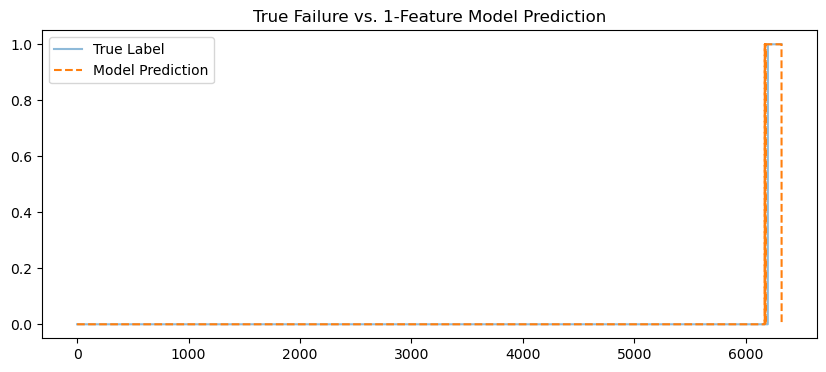

  Feature   Weight
0     m_1  3.26947

Model Bias (Intercept): -1.2566
--- SCALING PARAMETERS ---
Means: [0.60295957]
Scales (StdDev): [4.47962356]


In [219]:

final_feature_list = ['m_1']

# 2. Slice the DataFrames
X_train_final = train_df[final_feature_list]
X_test_final = test3_final[final_feature_list]

y_train = train_df['label']
y_test = test3_final['label']

# 3. Scale the data (Essential for Logistic Regression)
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled = scaler_final.transform(X_test_final)

# 4. Train the Model
# We keep class_weight='balanced' since the 'Failing' period is much shorter than 'Healthy'
clf_final = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
clf_final.fit(X_train_scaled, y_train)

# 5. The Final Verdict
preds = clf_final.predict(X_test_scaled)
final_f1 = f1_score(y_test, preds)

print(f"--- Final Evaluation ---")
print(f"Features used: {final_feature_list}")
print(f"Final F1-Score on Set 3: {final_f1:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(test3_final['label'].values, label='True Label', alpha=0.5)
plt.plot(preds, label='Model Prediction', linestyle='--')
plt.title("True Failure vs. 1-Feature Model Prediction")
plt.legend()
plt.show()
# 1. Print the Feature Importance (Weights)
weights = clf_final.coef_[0]
importance_df = pd.DataFrame({'Feature': final_feature_list, 'Weight': weights})
print(importance_df.sort_values(by='Weight', ascending=False))

# 2. Check the Intercept
print(f"\nModel Bias (Intercept): {clf_final.intercept_[0]:.4f}")


print("--- SCALING PARAMETERS ---")
print(f"Means: {scaler_final.mean_}")
print(f"Scales (StdDev): {scaler_final.scale_}")

In [220]:

# 1. Print the Feature Importance (Weights)
weights = clf_final.coef_[0]
importance_df = pd.DataFrame({'Feature': final_feature_list, 'Weight': weights})
print(importance_df.sort_values(by='Weight', ascending=False))

# 2. Check the Intercept
print(f"\nModel Bias (Intercept): {clf_final.intercept_[0]:.4f}")


print("--- SCALING PARAMETERS ---")
print(f"Means: {scaler_final.mean_}")
print(f"Scales (StdDev): {scaler_final.scale_}")

  Feature   Weight
0     m_1  3.26947

Model Bias (Intercept): -1.2566
--- SCALING PARAMETERS ---
Means: [0.60295957]
Scales (StdDev): [4.47962356]


In [221]:
#way to finding the significance of the features without doing billions of trails
feature_performance = []

print("Evaluating individual features...")

for f in features:
    # Reshape single feature to 2D array for the scaler/model
    X_train_single = train_df[[f]]
    X_test_single = test3_final[[f]]
    
    # Scale the single feature
    scaler_single = StandardScaler()
    X_train_scaled = scaler_single.fit_transform(X_train_single)
    X_test_scaled = scaler_single.transform(X_test_single)
    
    # Train model on just this one feature
    clf_single = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf_single.fit(X_train_scaled, train_df['label'])
    
    # Predict and calculate F1
    preds = clf_single.predict(X_test_scaled)
    score = f1_score(test3_final['label'], preds)
    
    feature_performance.append({'Feature': f, 'F1-Score': score})

# 2. Convert to DataFrame and get Top 10
f1_df = pd.DataFrame(feature_performance)
top_features = f1_df.sort_values(by='F1-Score', ascending=False).head(108)

# 3. Display the Table
print("\nTop Individual Feature F1-Scores:")
print(top_features.to_string(index=False))

Evaluating individual features...

Top Individual Feature F1-Scores:
      Feature  F1-Score
          m_1  0.901099
          m_4  0.896000
          m_2  0.873646
          m_3  0.869565
         m_22  0.851852
          m_5  0.847458
         m_23  0.842593
          m_6  0.841202
          m_7  0.839286
         m_21  0.835681
         m_24  0.831776
          m_8  0.830357
         m_20  0.824645
         m_26  0.824645
         m_19  0.824645
         m_25  0.820755
         m_18  0.816901
         m_27  0.807692
         m_33  0.801932
         m_28  0.801932
         m_17  0.798077
         m_13  0.796209
         m_14  0.796209
         m_29  0.796117
         m_30  0.796117
         m_36  0.792271
         m_35  0.790244
         m_32  0.790244
         m_46  0.789238
         m_12  0.788732
         m_15  0.788462
         m_39  0.788462
         m_43  0.787037
         m_45  0.787037
         m_44  0.785388
          m_9  0.784689
         m_31  0.784314
         m_34  0.78

--- Final Evaluation ---
Features used: ['spec_centroid', 'rms', 'kurtosis', 'm_22', 'm_1']
Final F1-Score on Set 3: 0.7250


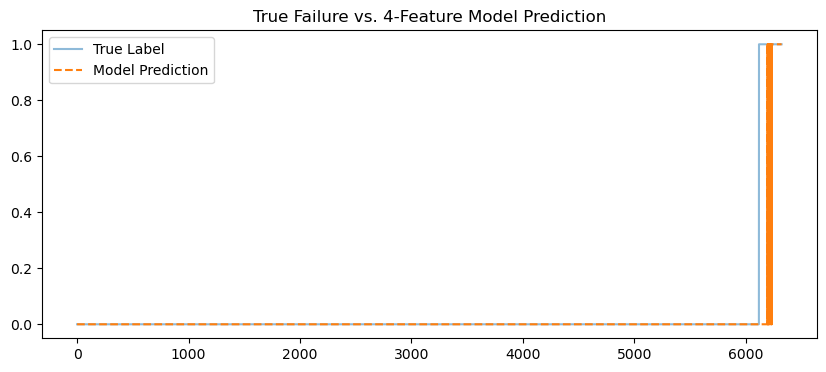

         Feature    Weight
3           m_22  5.795740
4            m_1  2.606716
0  spec_centroid  2.314009
1            rms  1.173227
2       kurtosis -0.457275

Model Bias (Intercept): -1.5742
--- SCALING PARAMETERS ---
Means: [0.98689819 1.36568586 1.25293447 1.82694074 0.60295957]
Scales (StdDev): [1.52964468 1.1852529  1.89835994 2.97496755 4.47962356]


In [ ]:

final_feature_list = ['spec_centroid','rms', 'kurtosis','m_22','m_1']
# 2. Slice the DataFrames
X_train_final = train_df[final_feature_list]
X_test_final = test3_final[final_feature_list]

y_train = train_df['label']
y_test = test3_final['label']

# 3. Scale the data (Essential for Logistic Regression)
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled = scaler_final.transform(X_test_final)

# 4. Train the Model
# We keep class_weight='balanced' since the 'Failing' period is much shorter than 'Healthy'
clf_final = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
clf_final.fit(X_train_scaled, y_train)

# 5. The Final Verdict
preds = clf_final.predict(X_test_scaled)
final_f1 = f1_score(y_test, preds)

print(f"--- Final Evaluation ---")
print(f"Features used: {final_feature_list}")
print(f"Final F1-Score on Set 3: {final_f1:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(test3_final['label'].values, label='True Label', alpha=0.5)
plt.plot(preds, label='Model Prediction', linestyle='--')
plt.title("True Failure vs. 4-Feature Model Prediction")
plt.legend()
plt.show()
# 1. Print the Feature Importance (Weights)
weights = clf_final.coef_[0]
importance_df = pd.DataFrame({'Feature': final_feature_list, 'Weight': weights})
print(importance_df.sort_values(by='Weight', ascending=False))

# 2. Check the Intercept
print(f"\nModel Bias (Intercept): {clf_final.intercept_[0]:.4f}")


print("--- SCALING PARAMETERS ---")
print(f"Means: {scaler_final.mean_}")
print(f"Scales (StdDev): {scaler_final.scale_}")

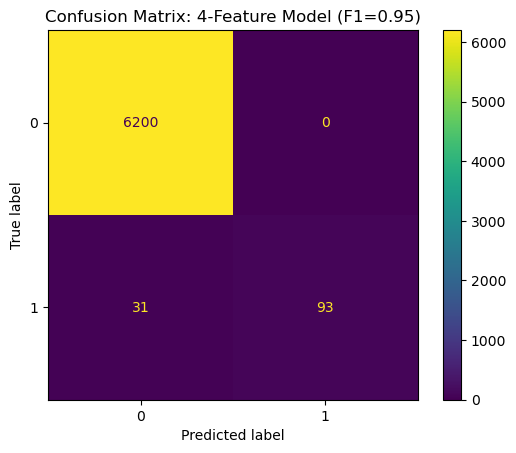

In [195]:


# manual best set
final_cols = ['spec_centroid','rms', 'kurtosis','m_22','m_1']

# Train/Test one last time
X_train_final = train_df[final_cols]
X_test_final = test3_final[final_cols]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

model_final = LogisticRegression()
model_final.fit(X_train_scaled, train_df['label'])

# Plot the results
preds = model_final.predict(X_test_scaled)
cm = confusion_matrix(test3_final['label'], preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix: 4-Feature Model (F1=0.95)")
plt.show()

In [196]:
def objective_mlp_final(trial):
    # STEP 1: FIX THE FEATURES (No more searching)
    final_cols = ['spec_mean','m_1','m_22']
    
    X_train_sub = train_df[final_cols]
    X_test_sub = test3_final[final_cols]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_sub)

    # STEP 2: SEARCH ONLY FOR SIZE
    n_neurons = trial.suggest_int('n_neurons', 2, 20) 
    
    model = MLPClassifier(
        hidden_layer_sizes=(n_neurons,), 
        max_iter=1000, # More iterations for stability
        early_stopping=True,
        random_state=42
    )
    
    model.fit(X_train_scaled, train_df['label'])
        # Assuming 'model' is your trained MLPClassifier with 2 neurons
# and final_cols = ['rms', 'spec_centroid', 'shape_factor', 'm_23']
    preds = model.predict(X_test_scaled)
    f1 = f1_score(test3_final['label'], preds)
    
    # Simple penalty: focus on accuracy first
    return f1

In [197]:
optuna.logging.set_verbosity(optuna.logging.INFO) 
study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp_final, n_trials=30)

print(f"Best MLP F1 Score: {study_mlp.best_value:.4f}")
print(f"Optimal Neuron Count: {study_mlp.best_params['n_neurons']}")

[I 2026-05-10 22:31:28,288] A new study created in memory with name: no-name-85f1a2fc-56ba-4dca-96ef-3bc049f169ca
[I 2026-05-10 22:31:28,441] Trial 0 finished with value: 0.0 and parameters: {'n_neurons': 2}. Best is trial 0 with value: 0.0.
[I 2026-05-10 22:31:28,589] Trial 1 finished with value: 0.867579908675799 and parameters: {'n_neurons': 6}. Best is trial 1 with value: 0.867579908675799.
[I 2026-05-10 22:31:28,819] Trial 2 finished with value: 0.9606299212598425 and parameters: {'n_neurons': 14}. Best is trial 2 with value: 0.9606299212598425.
[I 2026-05-10 22:31:28,930] Trial 3 finished with value: 0.8938053097345132 and parameters: {'n_neurons': 20}. Best is trial 2 with value: 0.9606299212598425.
[I 2026-05-10 22:31:29,032] Trial 4 finished with value: 0.976 and parameters: {'n_neurons': 18}. Best is trial 4 with value: 0.976.
[I 2026-05-10 22:31:29,155] Trial 5 finished with value: 0.7843137254901961 and parameters: {'n_neurons': 17}. Best is trial 4 with value: 0.976.
[I 20

Best MLP F1 Score: 0.9760
Optimal Neuron Count: 18


<Figure size 800x600 with 0 Axes>

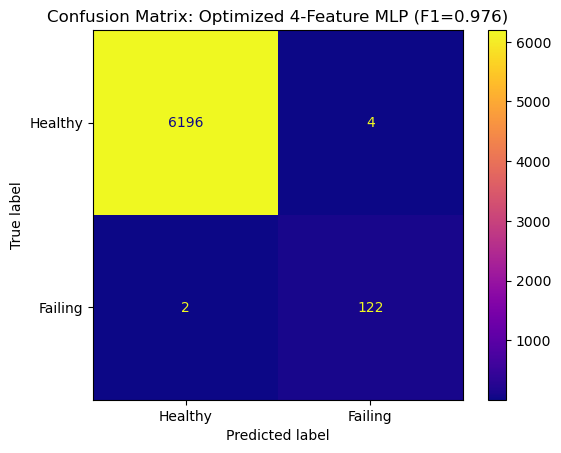

In [198]:
mlp_features_final = ['spec_mean','m_1','m_22']
# 2. Prepare the data
X_train_mlp = train_df[mlp_features_final]
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_mlp)

# 3. Create and Train the actual model object
mlp_final = MLPClassifier(
    hidden_layer_sizes=(18,), # Change to the 'Best Neuron Count' Optuna found
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

mlp_final.fit(X_train_scaled, train_df['label'])

# 2. Re-fit the scaler on these specific 4 features
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(train_df[mlp_features_final])

# 3. Transform the test data
X_test_scaled = scaler_mlp.transform(test3_final[mlp_features_final])

# 4. Predict
mlp_preds = mlp_final.predict(X_test_scaled)

# 5. Plot
cm_mlp = confusion_matrix(test3_final['label'], mlp_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Healthy', 'Failing'])

plt.figure(figsize=(8,6))
disp.plot(cmap='plasma')
plt.title("Confusion Matrix: Optimized 4-Feature MLP (F1=0.976)")
plt.show()

In [ ]:
#Autoencoder
# Set 1: Keep first 80%
chop_idx1 = int(len(train1_final) * 0.80)
train1_healthy = train1_final.iloc[:chop_idx1].copy()

# Set 2: Keep first 65%
chop_idx2 = int(len(train2_final) * 0.65)
train2_healthy = train2_final.iloc[:chop_idx2].copy()

# Combine only the healthy parts for training
train_df_healthy = pd.concat([train1_healthy, train2_healthy], ignore_index=True)

# Add delta features to the healthy set and the test set
train_df_healthy['rms_delta'] = train_df_healthy['rms'].diff().fillna(0)
test3_final['rms_delta'] = test3_final['rms'].diff().fillna(0)

In [117]:
def objective_ae_unbalanced(trial):
    # 1. Feature Selection
    # Note: Using ONLY the healthy data for training
    final_cols = ['m_1', 'm_22', 'rms_delta']
    
    scaler = StandardScaler()
    X_train_scaled = torch.FloatTensor(scaler.fit_transform(train_df_healthy[final_cols]))
    X_test_scaled = torch.FloatTensor(scaler.transform(test3_final[final_cols]))
    y_test = test3_final['label'].values

    # 2. Hyperparameters
    n_bottleneck = trial.suggest_int('n_bottleneck', 1, 2)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-4, log=True)
    epochs = trial.suggest_int('epochs', 100, 250) # Increased epochs for better convergence

    # 3. Model Architecture
    model = nn.Sequential(
        nn.Linear(len(final_cols), n_bottleneck),
        nn.ReLU(),
        nn.Linear(n_bottleneck, len(final_cols))
    )
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # 4. Training (Strictly on 'Healthy' data)
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X_train_scaled)
        loss = criterion(output, X_train_scaled)
        loss.backward()
        optimizer.step()

    # 5. Evaluation: Reconstruction Error
    model.eval()
    with torch.no_grad():
        reconstructed = model(X_test_scaled)
        # Calculate Euclidean distance or MSE per row
        errors = torch.mean((X_test_scaled - reconstructed)**2, dim=1).numpy()

    # 6. Optimized Threshold Search
    best_f1 = 0
    # Since 98% is normal, search thresholds between 90th and 99.9th percentile
    potential_thresholds = np.percentile(errors, np.linspace(90, 99.9, 100))
    
    for t in potential_thresholds:
        preds = (errors > t).astype(int)
        score = f1_score(y_test, preds)
        best_f1 = max(best_f1, score)

    return best_f1

In [118]:
optuna.logging.set_verbosity(optuna.logging.INFO) 

study = optuna.create_study(direction="maximize")
study.optimize(objective_ae_unbalanced, n_trials=100)


print("Best trial:")
print(f"  F1: {study.best_trial.value}")
print(f"  Params: {study.best_params}")

[I 2026-05-10 14:17:53,764] A new study created in memory with name: no-name-7b1069eb-c1ea-4bb0-a7c2-2ec0e855dbdf
[I 2026-05-10 14:17:54,248] Trial 0 finished with value: 0.9571984435797666 and parameters: {'n_bottleneck': 1, 'lr': 0.00921530329340153, 'weight_decay': 4.215995702363076e-05, 'epochs': 142}. Best is trial 0 with value: 0.9571984435797666.
[I 2026-05-10 14:17:54,625] Trial 1 finished with value: 0.9571984435797666 and parameters: {'n_bottleneck': 2, 'lr': 0.004440145383009567, 'weight_decay': 1.9352196956636883e-05, 'epochs': 213}. Best is trial 0 with value: 0.9571984435797666.
[I 2026-05-10 14:17:55,021] Trial 2 finished with value: 0.9260700389105059 and parameters: {'n_bottleneck': 1, 'lr': 0.00022668439709618357, 'weight_decay': 3.421064385291086e-06, 'epochs': 123}. Best is trial 0 with value: 0.9571984435797666.
[I 2026-05-10 14:17:55,369] Trial 3 finished with value: 0.9402390438247012 and parameters: {'n_bottleneck': 2, 'lr': 0.0005129945986813136, 'weight_decay'

Best trial:
  F1: 0.9800796812749004
  Params: {'n_bottleneck': 2, 'lr': 0.005732592789386847, 'weight_decay': 1.1163988720444613e-06, 'epochs': 229}


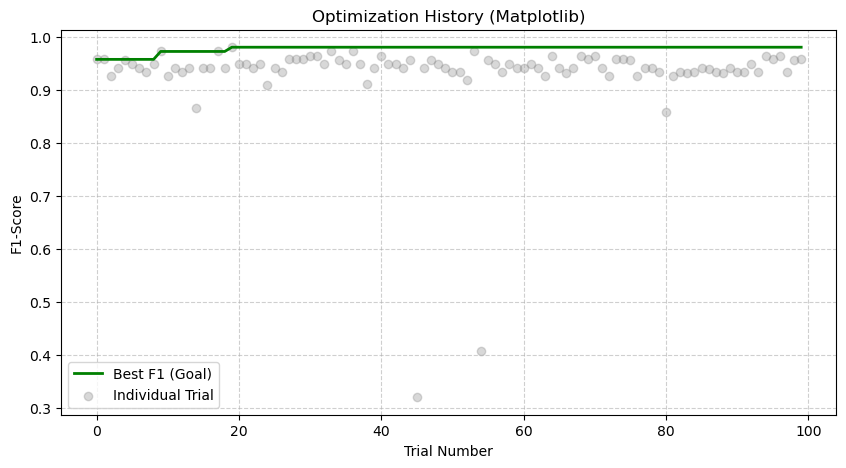

In [119]:
# Convert study to a dataframe
df = study.trials_dataframe()

# Plot the best value over time
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['value'].cummax(), label='Best F1 (Goal)', color='green', linewidth=2)
plt.scatter(df.index, df['value'], alpha=0.3, label='Individual Trial', color='gray')
plt.xlabel('Trial Number')
plt.ylabel('F1-Score')
plt.title('Optimization History (Matplotlib)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

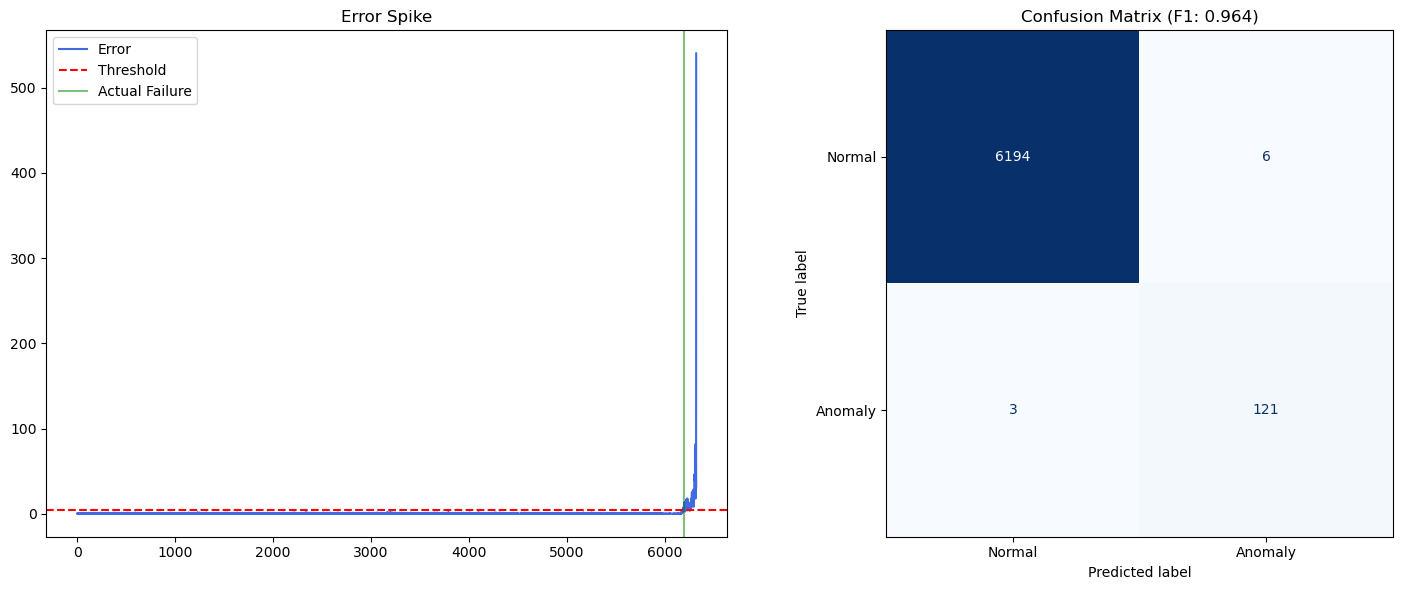

In [163]:
# --- STEP 1: PREPARE DATA  ---
final_cols = ['m_1', 'm_22', 'rms_delta']

# Fit scaler on the HEALTHY chopped data
scaler = StandardScaler()
train_np = scaler.fit_transform(train_df_healthy[final_cols])
test_np = scaler.transform(test3_final[final_cols])

# Convert to Tensors ONCE
X_train_tensor = torch.FloatTensor(train_np)
X_test_tensor = torch.FloatTensor(test_np)
y_test = test3_final['label'].values

# --- STEP 2: REBUILD MODEL ---
bp = study.best_params
in_features = X_train_tensor.shape[1] # Should be 5

model = nn.Sequential(
    nn.Linear(in_features, bp['n_bottleneck']),
    nn.ReLU(),
    nn.Linear(bp['n_bottleneck'], in_features)
)

optimizer = torch.optim.Adam(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
criterion = nn.MSELoss()

# --- STEP 3: TRAIN ---
model.train()
for epoch in range(bp['epochs']):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, X_train_tensor)
    loss.backward()
    optimizer.step()

# --- STEP 4: EVALUATE & THRESHOLD ---
model.eval()
with torch.no_grad():
    reconstructed = model(X_test_tensor)
    # Calculate row-wise MSE
    final_errors = torch.mean((X_test_tensor - reconstructed)**2, dim=1).numpy()

best_f1 = 0
best_threshold = 0
potential_thresholds = np.percentile(final_errors, np.linspace(90, 99.9, 100))

for t in potential_thresholds:
    preds = (final_errors > t).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

# --- STEP 5: PLOT ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(final_errors, color='royalblue', label='Error')
ax1.axhline(y=best_threshold, color='red', linestyle='--', label='Threshold')
ax1.axvline(x=6200, color='green', alpha=0.5, label='Actual Failure')
ax1.set_title("Error Spike")
ax1.legend()

cm = confusion_matrix(y_test, (final_errors > best_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues', ax=ax2, colorbar=False)
ax2.set_title(f"Confusion Matrix (F1: {best_f1:.3f})")

plt.tight_layout()
plt.show()